# Pricing Options: From Black–Scholes to Monte Carlo
## Step 1 — What is an option and why do we need a model?

**Target audience:** second-year undergraduate students  
**Goal of this notebook:** introduce options, their payoffs, and the Black–Scholes idea in a clear and intuitive way.

---

### Learning objectives

At the end of this notebook, the student should be able to:

- explain what an option is,
- distinguish between a **call** and a **put**,
- distinguish between **European**, **American**, and **Bermudan** options,
- write the payoff of a European call and a European put,
- understand why a mathematical model is needed to price an option,
- state the main idea of the **Black–Scholes model**.


## 1. Why do we study options?

In finance, many products derive their value from another asset such as a stock, an index, or a commodity. These products are called **derivatives**.

An **option** is one of the most important derivatives. It gives its holder the **right**, but not the obligation, to buy or sell an asset at a pre-agreed price on or before a certain date.

Options are widely used:

- to **hedge risk**,
- to **speculate** on future price movements,
- and to **build more complex financial strategies**.

The main question is therefore:

> **How can we determine the fair value of an option today?**

To answer this, we need a mathematical model for the evolution of asset prices. One of the most famous models is the **Black–Scholes model**.


## 2. What is an option?

An option is a contract between two parties:

- the **buyer** of the option,
- and the **seller** (also called the writer).

The buyer pays a price today, called the **premium**, in exchange for a right.

There are two basic types of options:

### 2.1 Call option
A **call option** gives the holder the right to **buy** the underlying asset at a fixed price.

### 2.2 Put option
A **put option** gives the holder the right to **sell** the underlying asset at a fixed price.

The fixed price written in the contract is called the **strike price**, usually denoted by $K$.

The date at which the option can be exercised is called the **maturity** or **expiration date**, usually denoted by $T$.


## 3. Different types of options

There are several ways to classify options. The two most important classifications are:

1. **by payoff type**,
2. **by exercise rule**.

### 3.1 Classification by payoff type

#### Call option
A call is profitable when the market price of the asset is **above** the strike price.

If the asset price at maturity is denoted by $S_T$, then the payoff of a European call is:

$$
\max(S_T - K, 0).
$$

#### Put option
A put is profitable when the market price of the asset is **below** the strike price.

Its payoff at maturity is:

$$
\max(K - S_T, 0).
$$

### 3.2 Classification by exercise rule

#### European option
A **European option** can only be exercised **at maturity**.

#### American option
An **American option** can be exercised **at any time up to maturity**.

#### Bermudan option
A **Bermudan option** can be exercised on a set of specific dates before maturity.

### 3.3 Other common families

Beyond plain vanilla call and put options, there are many more sophisticated contracts:

- **Digital (binary) options**,
- **Barrier options**,
- **Asian options**,
- **Lookback options**.

In this notebook, we will begin with the simplest and most important case:

> **European call and put options.**


## 4. Understanding the payoff

The **payoff** of an option is the amount received at maturity.

For a European call,

$$
\text{Payoff}_{\text{call}} = \max(S_T - K, 0).
$$

This means:

- if $S_T > K$, the holder exercises the option and gains $S_T - K$,
- if $S_T \le K$, the holder does not exercise and the payoff is $0$.

For a European put,

$$
\text{Payoff}_{\text{put}} = \max(K - S_T, 0).
$$

This means:

- if $S_T < K$, the holder exercises the option and gains $K - S_T$,
- if $S_T \ge K$, the holder does not exercise and the payoff is $0$.


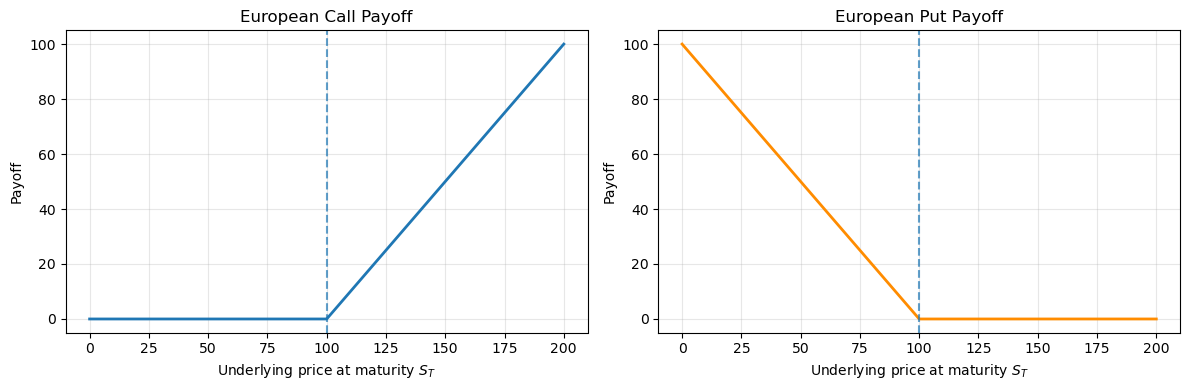

In [1]:
import numpy as np
import matplotlib.pyplot as plt

K = 100
S = np.linspace(0, 200, 500)

call_payoff = np.maximum(S - K, 0)
put_payoff = np.maximum(K - S, 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(S, call_payoff, lw=2)
axes[0].axvline(K, linestyle='--', alpha=0.7)
axes[0].set_title('European Call Payoff')
axes[0].set_xlabel('Underlying price at maturity $S_T$')
axes[0].set_ylabel('Payoff')
axes[0].grid(True, alpha=0.3)

axes[1].plot(S, put_payoff, lw=2, color='darkorange')
axes[1].axvline(K, linestyle='--', alpha=0.7)
axes[1].set_title('European Put Payoff')
axes[1].set_xlabel('Underlying price at maturity $S_T$')
axes[1].set_ylabel('Payoff')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Interpretation of the graphs

- The **call payoff** is zero when the stock ends below the strike.
  It increases linearly once $S_T > K$.

- The **put payoff** is positive when the stock ends below the strike.
  It becomes zero once $S_T \ge K$.

These simple payoff shapes are the starting point of option pricing theory.


## 5. Why is pricing an option difficult?

Pricing an option is not as simple as pricing a stock.

A stock has a directly observed market price today.  
An option, however, depends on the **future evolution** of the stock price, which is uncertain.

For example:

- if the stock price rises a lot, a call option may become very valuable,
- if the stock price falls, the same call may end up worthless.

So the value of an option depends on:

- the current stock price,
- the strike price,
- the time remaining until maturity,
- the volatility of the stock,
- and interest rates.

In other words, option pricing is a problem of **pricing uncertainty**.


## 6. Why do we need a model?

Since the future is uncertain, we need a mathematical description of how stock prices may evolve through time.

A model helps us answer questions such as:

- What are the possible future stock prices?
- How likely are these outcomes?
- What is the expected value of the option payoff?
- What is a fair price today?

The purpose of a pricing model is not to predict the future perfectly, but to provide a **consistent and rational framework** for valuation.


## 7. The Black–Scholes idea

The Black–Scholes model was developed to price options under a set of simplifying assumptions.

Its key idea is the following:

> If we can model the random evolution of the stock price, and if markets do not allow arbitrage opportunities, then we can derive a fair price for an option.

The Black–Scholes framework combines:

1. a model for the stock price,
2. the principle of **no arbitrage**,
3. and a replication argument showing that the option can be hedged dynamically.

This leads to the famous **Black–Scholes formula** for European options.


## 8. What does Black–Scholes model?

In the Black–Scholes framework, the asset price $S_t$ is modeled as a **continuous-time stochastic process**.

A simplified mathematical form is:

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.
$$

At first sight, this notation may look intimidating. The intuition is simpler:

- $\mu$ represents the **average trend**,
- $\sigma$ represents the **volatility**,
- $W_t$ represents the source of randomness.

This process is called **geometric Brownian motion**.

We will come back to this model carefully in the next notebook sections.


## 9. Why is this useful for option pricing?

If we know how the stock evolves, then we can describe the option payoff at maturity.

For a European call, the payoff is

$$
(S_T - K)^+ = \max(S_T - K, 0).
$$

So once we have a model for $S_T$, we can try to determine the present value of this future payoff.

This is exactly the role of Black–Scholes:

- model the stock price,
- understand the distribution of the terminal price $S_T$,
- and compute the fair price of the option today.


## 10. Summary

In this first step, we introduced the basic language of option pricing.

### Main ideas to remember

- An **option** is a derivative contract.
- A **call** gives the right to buy; a **put** gives the right to sell.
- European options are exercised **only at maturity**.
- The payoff of a European call is $\max(S_T-K,0)$.
- The payoff of a European put is $\max(K-S_T,0)$.
- Pricing an option is difficult because it depends on an **uncertain future price**.
- The **Black–Scholes model** provides a mathematical framework to model this uncertainty.


## 11. What comes next?

In the next step, we can develop one of the following sections:

1. **The assumptions of the Black–Scholes model**
2. **Geometric Brownian motion in more detail**
3. **The Black–Scholes formula for European call and put options**
4. **A first Monte Carlo simulation for option pricing**

---

**Suggested next step:** start with the **assumptions of the Black–Scholes model**, because they explain what the model can and cannot do.
